# Exploratory Data Analysis of Facebook Post Performance

This notebook explores engagement patterns in Facebook posts to understand which types of posts perform better.

**Sections:**
1. Data Loading
2. Initial Data Inspection
3. Data Cleaning
4. Missing Value Analysis
5. Feature Engineering
6. Engagement Metric Distributions
7. Algorithmic Exposure vs Audience Engagement
8. Posting Time Analysis
9. Key Findings Summary

## 1. Data Loading

Import libraries and load the Facebook analytics dataset.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

data_path = Path("../data/facebook_posts.csv")
df = pd.read_csv(data_path)

df.head()

,Post ID,Page ID,Page name,Title,Duration (sec),Publish time,Permalink,Post type,Data comment,Date,...,Comments,Distribution,Impressions,Interactions,Reactions,Saves,Shares,Viewers,Average Seconds viewed,Seconds viewed
0,10235051703501121,1461428297,Liz Izakson Mashal,#זהו_זה_קורה!\n\nספטמבר מביא איתו התחלות חדשות...,0,09/01/2025 22:26,https://www.facebook.com/liz.izakson/posts/pfb...,Photo,NaN,Lifetime,...,57.0,--,1479.0,126.0,102.0,0.0,6.0,1182.0,NaN,NaN
1,10237757303779437,1461428297,Liz Izakson Mashal,אתמול כתבתי כאן על החוויות ממפגש החתימות במודי...,0,03/04/2026 09:50,https://www.facebook.com/liz.izakson/posts/pfb...,Content,NaN,Lifetime,...,0.0,NaN,NaN,1.0,1.0,0.0,0.0,25.0,NaN,NaN
2,10237757281258874,1461428297,Liz Izakson Mashal,"⁨ ⁨ רגע לפני שהמלחמה התחילה והכל נסגר,\nוהתכנס...",29,03/04/2026 09:49,https://www.facebook.com/reel/2482153035588530/,Reel,NaN,Lifetime,...,0.0,-0.3x,140.0,8.0,8.0,0.0,1.0,127.0,7.255,1073.74
3,10237734887059033,1461428297,Liz Izakson Mashal,"רגע לפני שהתחילה עוד מלחמה שסוגרת אותנו בבתים,...",0,03/03/2026 09:15,https://www.facebook.com/liz.izakson/posts/pfb...,Photo,NaN,Lifetime,...,11.0,--,599.0,35.0,25.0,0.0,0.0,516.0,NaN,NaN
4,10237705072153679,1461428297,Liz Izakson Mashal,"בין הריצות לממ״ד לדאגה הקיומית,\n\nנתקלתי בסקי...",0,03/01/2026 08:58,https://www.facebook.com/liz.izakson/posts/pfb...,Content,NaN,Lifetime,...,2.0,--,197.0,14.0,13.0,0.0,0.0,160.0,NaN,NaN


## 2. Initial Data Inspection

Check the dataset shape, column types, and how many non-null values exist per column.

In [4]:
# Dataset shape, column types, and null counts at a glance
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Post ID                 111 non-null    int64  
 1   Page ID                 111 non-null    int64  
 2   Page name               111 non-null    str    
 3   Title                   111 non-null    str    
 4   Duration (sec)          111 non-null    int64  
 5   Publish time            111 non-null    str    
 6   Permalink               111 non-null    str    
 7   Post type               111 non-null    str    
 8   Data comment            0 non-null      float64
 9   Date                    111 non-null    str    
 10  Views                   111 non-null    int64  
 11  Comments                79 non-null     float64
 12  Distribution            78 non-null     str    
 13  Impressions             78 non-null     float64
 14  Interactions            79 non-null     float64
 15  

## 3. Data Cleaning

Normalise column names (lowercase, no special characters) and coerce metric columns to numeric types.
We also take a first look at the post type distribution.

In [5]:
# Normalize column names: lowercase, strip whitespace, replace special characters with underscores
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(r"[^\w]+", "_", regex=True)
)

print("Cleaned column names:")
print(df.columns.tolist())

print("\nPost type distribution:")
print(df["post_type"].value_counts())

Cleaned column names:
['post_id', 'page_id', 'page_name', 'title', 'duration_sec_', 'publish_time', 'permalink', 'post_type', 'data_comment', 'date', 'views', 'comments', 'distribution', 'impressions', 'interactions', 'reactions', 'saves', 'shares', 'viewers', 'average_seconds_viewed', 'seconds_viewed']

Post type distribution:
post_type
Photo      86
Content    18
Reel        6
Link        1
Name: count, dtype: int64


In [6]:
# Coerce metric columns to numeric (non-parseable values become NaN)
numeric_cols = [
    "views", "comments", "impressions", "interactions",
    "reactions", "saves", "shares", "viewers",
    "average_seconds_viewed", "seconds_viewed",
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

## 4. Missing Value Analysis

Identify which columns contain missing values and determine whether the missingness is structural
(i.e. a metric is simply not applicable to that post type) or genuinely absent.

In [7]:
# Count missing values per metric column
df[numeric_cols].isna().sum()

views                       0
comments                   32
impressions                33
interactions               32
reactions                  32
saves                      32
shares                     32
viewers                    32
average_seconds_viewed    105
seconds_viewed            105
dtype: int64

In [8]:
# Verify that video-only metrics (average_seconds_viewed, seconds_viewed) are
# present exclusively for Reels — explaining why they are missing for all other types.
df.groupby("post_type")[["average_seconds_viewed", "seconds_viewed"]].count()

,average_seconds_viewed,seconds_viewed
post_type,,
Content,0,0
Link,0,0
Photo,0,0
Reel,6,6


As expected, `average_seconds_viewed` and `seconds_viewed` are only populated for **Reel** posts.
Their missingness in other rows is structural, not a data quality issue.

## 5. Feature Engineering

### 5.1 Date & Time Features

Parse the `publish_time` column as a datetime, apply a known **+10 hour timezone correction**
(the Facebook export uses a UTC offset that does not match the actual local posting times),
and extract useful temporal features.

In [9]:
# Parse publish_time as datetime
df["publish_time"] = pd.to_datetime(df["publish_time"], errors="coerce")

# Spot-check raw timestamps before correction
df[["publish_time", "title"]].head(5)

,publish_time,title
0,2025-09-01 22:26:00,#זהו_זה_קורה!\n\nספטמבר מביא איתו התחלות חדשות...
1,2026-03-04 09:50:00,אתמול כתבתי כאן על החוויות ממפגש החתימות במודי...
2,2026-03-04 09:49:00,"⁨ ⁨ רגע לפני שהמלחמה התחילה והכל נסגר,\nוהתכנס..."
3,2026-03-03 09:15:00,"רגע לפני שהתחילה עוד מלחמה שסוגרת אותנו בבתים,..."
4,2026-03-01 08:58:00,"בין הריצות לממ״ד לדאגה הקיומית,\n\nנתקלתי בסקי..."


In [10]:
# Apply the +10 h correction to align with actual posting times
df["publish_time"] = df["publish_time"] + pd.Timedelta(hours=10)

# Extract temporal features
df["date"]    = df["publish_time"].dt.date
df["time"]    = df["publish_time"].dt.time
df["hour"]    = df["publish_time"].dt.hour
df["weekday"] = df["publish_time"].dt.day_name()

# Verify corrected timestamps
df.sort_values("publish_time", ascending=False)[["date", "time", "weekday", "title"]].head(10)

,date,time,weekday,title
1,2026-03-04,19:50:00,Wednesday,אתמול כתבתי כאן על החוויות ממפגש החתימות במודי...
2,2026-03-04,19:49:00,Wednesday,"⁨ ⁨ רגע לפני שהמלחמה התחילה והכל נסגר,\nוהתכנס..."
3,2026-03-03,19:15:00,Tuesday,"רגע לפני שהתחילה עוד מלחמה שסוגרת אותנו בבתים,..."
4,2026-03-01,18:58:00,Sunday,"בין הריצות לממ״ד לדאגה הקיומית,\n\nנתקלתי בסקי..."
5,2026-02-28,18:59:00,Saturday,"קצת קולטורה לממ""ד 📚✨\n\n""בין המסדרונות""/ליז אי..."
6,2026-02-28,10:53:00,Saturday,"סופרי וסופרות ""התחנה"" מתגייסים להעלאת המוראל. ..."
7,2026-02-28,10:42:00,Saturday,"סופרי ""התחנה"" מתגייסים להעלות את המורל ומעדכני..."
8,2026-02-27,07:00:00,Friday,יאללה יוצאת שוב לשטח.\n\nכי בסוף זה החיים.\n\n...
9,2026-02-25,19:15:00,Wednesday,"חזרתי למקום שבו התחלתי לכתוב, \n\nלמקום שבו הכ..."
10,2026-02-24,07:56:00,Tuesday,ענת כתבה על #בין_המסדרונות מילים שנגעו בי בדיו...


### 5.4 Post Origin

Using the `page_name` column, we classify each post by where it originated:

- **My Post** — `page_name == "Liz Izakson Mashal"`: posted directly on Liz's own page (includes both original content and shares she made herself)
- **Tagged** — all other page names: posts that appeared on her page because another user tagged her

Tagged posts originate from a different page entirely and would skew the analysis, so we remove them from the main dataset and store them separately in `df_tagged`.

In [ ]:
# Classify post origin based on page_name:
# - "My Post": posted on Liz's own page
# - "Tagged": appeared on her page because someone else tagged her
df["post_origin"] = df["page_name"].apply(
    lambda x: "My Post" if x == "Liz Izakson Mashal" else "Tagged"
)

# Separate tagged posts — they originate from other pages and skew the analysis
df_tagged = df[df["post_origin"] == "Tagged"].copy()
df = df[df["post_origin"] == "My Post"].copy()

print(f"Main analysis: {len(df)} posts (Liz's own page)")
print(f"Excluded (tagged by others): {len(df_tagged)} posts")
print()
print("Post type breakdown after filtering:")
print(df["post_type"].value_counts())

### 5.2 Engagement Rate

**Engagement rate** = `interactions / impressions`.

This normalises raw interaction counts by reach, making posts with different impression volumes
comparable. A post with few impressions but many interactions scores higher than a widely-distributed
post that generated little response.

In [11]:
# Guard against division by zero by replacing 0 impressions with NaN
df["engagement_rate"] = df["interactions"] / df["impressions"].replace(0, np.nan)

df["engagement_rate"].describe()

count    78.000000
mean      0.061747
std       0.020920
min       0.009279
25%       0.050555
50%       0.064517
75%       0.077969
max       0.113208
Name: engagement_rate, dtype: float64

### 5.3 Post Category Classification

We classify each post into one of four quadrants based on whether its **impressions** and
**engagement rate** are above or below the dataset median:

| | High Engagement Rate | Low Engagement Rate |
|---|---|---|
| **High Impressions** | Viral | Algorithm Pushed |
| **Low Impressions** | Audience Favorite | Low Performance |

In [12]:
impressions_median = df["impressions"].median()
engagement_median  = df["engagement_rate"].median()

def classify_post(row):
    high_imp = row["impressions"] >= impressions_median
    high_eng = row["engagement_rate"] >= engagement_median
    if high_imp and high_eng:
        return "Viral"
    elif not high_imp and high_eng:
        return "Audience Favorite"
    elif high_imp and not high_eng:
        return "Algorithm Pushed"
    else:
        return "Low Performance"

df["post_category"] = df.apply(classify_post, axis=1)

print("Posts per category:")
print(df["post_category"].value_counts())

print("\nCategory breakdown by post type:")
pd.crosstab(df["post_category"], df["post_type"])

Posts per category:
post_category
Low Performance      51
Audience Favorite    21
Algorithm Pushed     21
Viral                18
Name: count, dtype: int64

Category breakdown by post type:


post_type,Content,Link,Photo,Reel
post_category,,,,
Algorithm Pushed,0,0,20,1
Audience Favorite,10,0,8,3
Low Performance,8,1,40,2
Viral,0,0,18,0


### What does a "Content" post actually contain?

To clarify the difference between **Content** and **Photo** post types, we display sample titles
and metrics for each type. This makes it clear whether "Content" refers to text-only posts,
link shares, or something else in this specific dataset.

In [ ]:
# Show sample posts for each type to compare their structure and content
for post_type in ["Content", "Photo"]:
    subset = df[df["post_type"] == post_type][["title", "post_type", "impressions", "interactions", "engagement_rate"]]
    print(f"=== {post_type} posts (n={len(subset)}) ===")
    print(subset.head(8).to_string(index=False))
    print()

## 6. Engagement Metric Distributions

Examine the distribution of each engagement variable to understand scale, variability, and skewness.
This informs how we interpret averages and identify high-performing outliers.

In [13]:
engagement_vars = ["reactions", "comments", "shares", "saves", "impressions", "interactions"]

df[engagement_vars].describe()

,reactions,comments,shares,saves,impressions,interactions
count,79.000000,79.000000,79.000000,79.000000,78.000000,79.000000
mean,44.164557,15.063291,0.810127,0.101266,1175.589744,55.936709
std,26.192791,11.252740,1.086938,0.411219,1618.027342,33.262878
min,1.000000,0.000000,0.000000,0.000000,140.000000,1.000000
25%,25.500000,6.500000,0.000000,0.000000,522.750000,32.500000
50%,42.000000,13.000000,1.000000,0.000000,862.500000,52.000000
75%,59.000000,20.000000,1.000000,0.000000,1160.750000,75.000000
max,118.000000,57.000000,6.000000,2.000000,12502.000000,144.000000


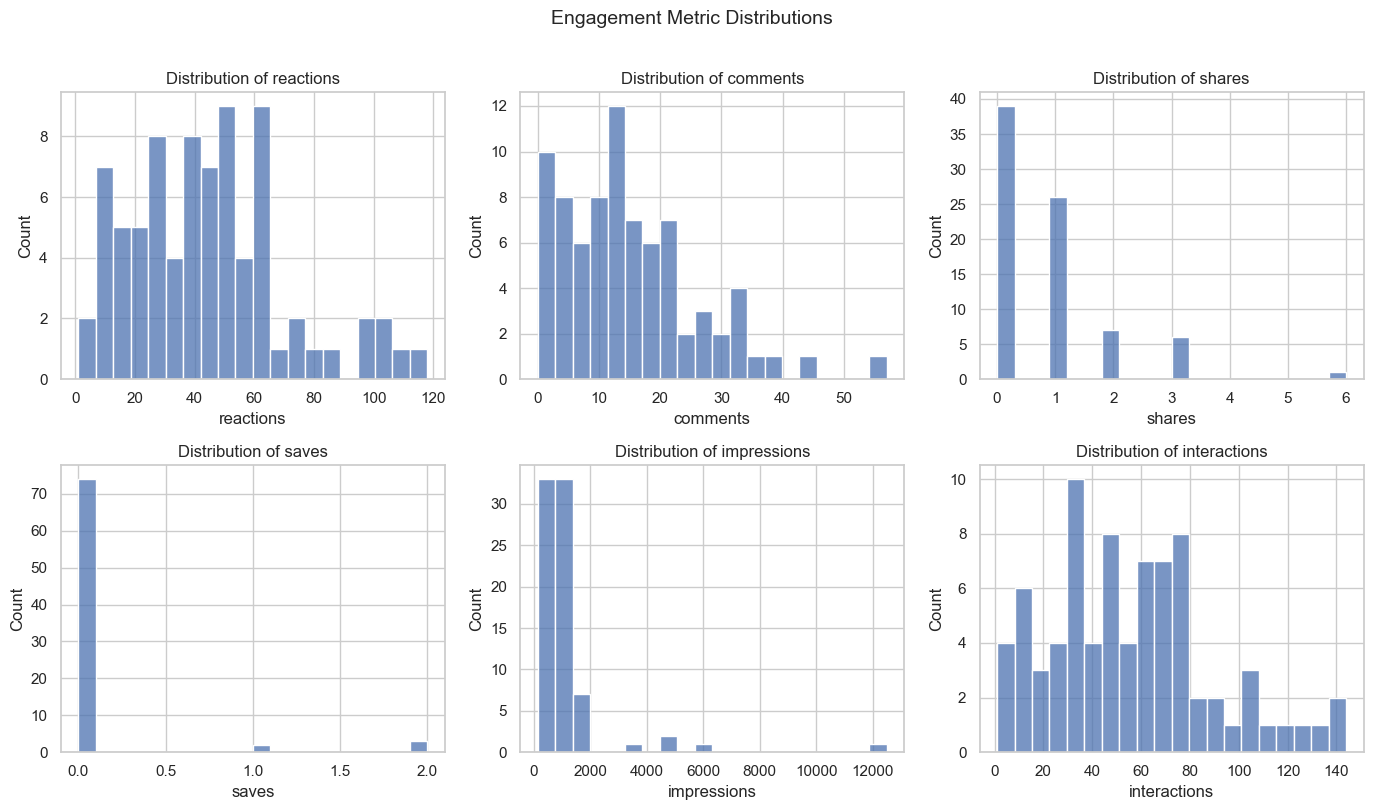

In [14]:
# Histogram for each engagement variable to visualise its distribution
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, var in zip(axes.flat, engagement_vars):
    sns.histplot(df[var].dropna(), bins=20, ax=ax)
    ax.set_title(f"Distribution of {var}")
    ax.set_xlabel(var)
    ax.set_ylabel("Count")

plt.suptitle("Engagement Metric Distributions", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

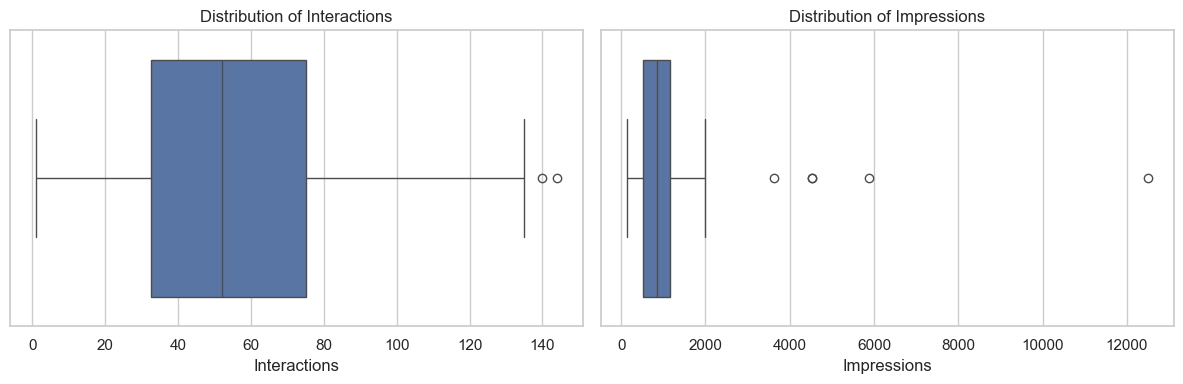

Interactions — mean: 55.9, median: 52.0, skew: 0.64
Impressions  — mean: 1175.6, median: 862.5, skew: 5.14

Correlation (interactions vs impressions): 0.591


In [15]:
# Side-by-side boxplots for the two most important metrics, plus summary statistics
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(x=df["interactions"], ax=axes[0])
axes[0].set_title("Distribution of Interactions")
axes[0].set_xlabel("Interactions")

sns.boxplot(x=df["impressions"], ax=axes[1])
axes[1].set_title("Distribution of Impressions")
axes[1].set_xlabel("Impressions")

plt.tight_layout()
plt.show()

print(f"Interactions — mean: {df['interactions'].mean():.1f}, median: {df['interactions'].median():.1f}, skew: {df['interactions'].skew():.2f}")
print(f"Impressions  — mean: {df['impressions'].mean():.1f}, median: {df['impressions'].median():.1f}, skew: {df['impressions'].skew():.2f}")
print(f"\nCorrelation (interactions vs impressions): {df[['interactions','impressions']].corr().iloc[0,1]:.3f}")

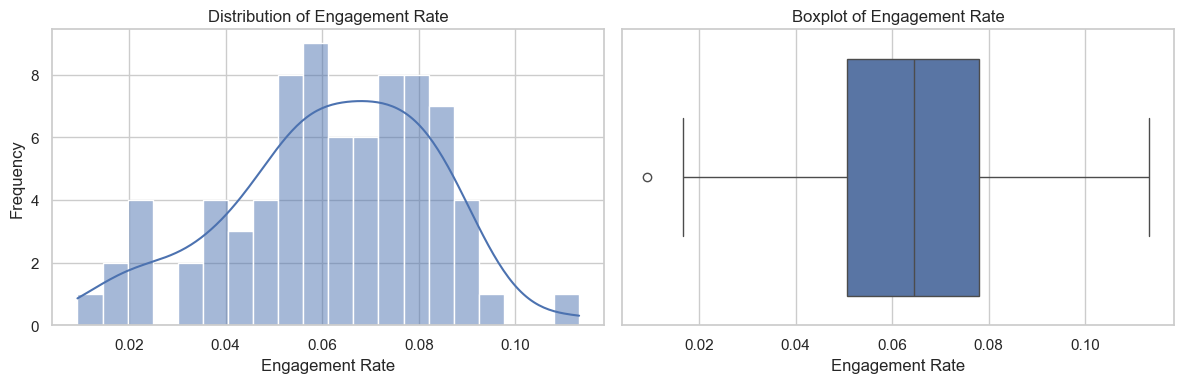

Engagement Rate — mean: 0.0617, median: 0.0645, skew: -0.42


In [16]:
# Engagement rate distribution — histogram with KDE + boxplot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["engagement_rate"].dropna(), bins=20, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Engagement Rate")
axes[0].set_xlabel("Engagement Rate")
axes[0].set_ylabel("Frequency")

sns.boxplot(x=df["engagement_rate"], ax=axes[1])
axes[1].set_title("Boxplot of Engagement Rate")
axes[1].set_xlabel("Engagement Rate")

plt.tight_layout()
plt.show()

print(f"Engagement Rate — mean: {df['engagement_rate'].mean():.4f}, median: {df['engagement_rate'].median():.4f}, skew: {df['engagement_rate'].skew():.2f}")

## 7. Algorithmic Exposure vs Audience Engagement

Post performance can be evaluated from two complementary perspectives:

1. **Algorithmic exposure** — how many people the platform showed the post to (impressions)
2. **Audience engagement** — how strongly viewers responded relative to reach (engagement rate)

Analysing both together reveals which posts the algorithm favoured versus which posts genuinely
resonated with the audience.

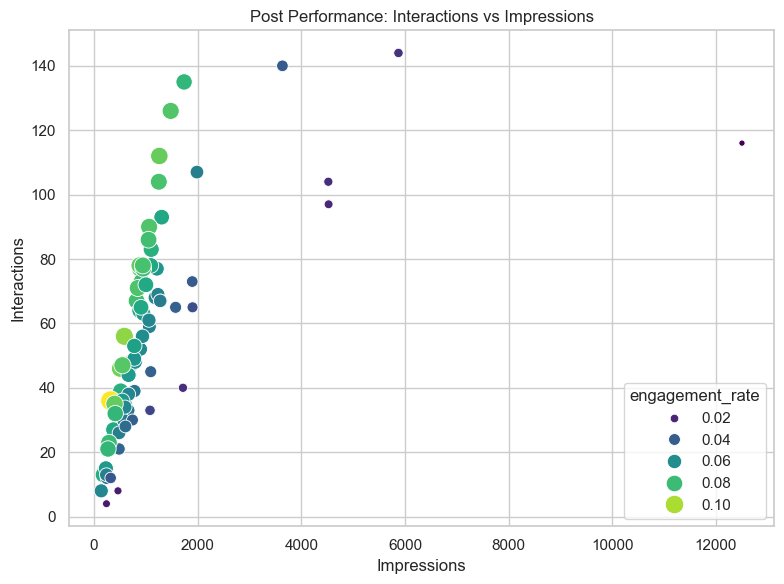

In [17]:
# Scatter: interactions vs impressions, point size/colour = engagement rate
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="impressions",
    y="interactions",
    hue="engagement_rate",
    size="engagement_rate",
    sizes=(20, 200),
    palette="viridis",
)

plt.title("Post Performance: Interactions vs Impressions")
plt.xlabel("Impressions")
plt.ylabel("Interactions")
plt.tight_layout()
plt.show()

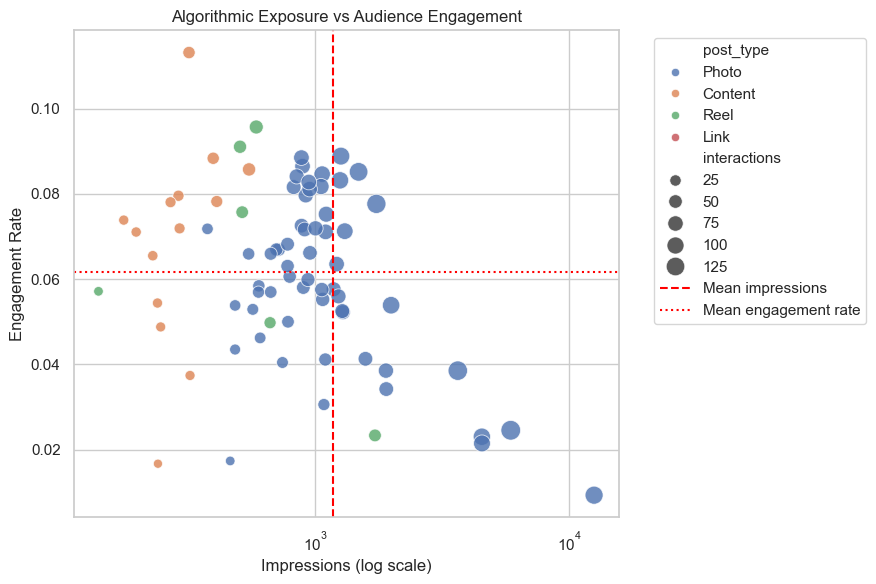

In [18]:
# Quadrant plot: impressions (log scale) vs engagement rate, coloured by post type
# Dashed lines mark the mean for each axis, dividing the chart into four quadrants.
impressions_mean = df["impressions"].mean()
engagement_mean  = df["engagement_rate"].mean()

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="impressions",
    y="engagement_rate",
    hue="post_type",
    size="interactions",
    sizes=(40, 200),
    alpha=0.8,
)

plt.xscale("log")
plt.axvline(impressions_mean, color="red", linestyle="--", label="Mean impressions")
plt.axhline(engagement_mean,  color="red", linestyle=":",  label="Mean engagement rate")

plt.xlabel("Impressions (log scale)")
plt.ylabel("Engagement Rate")
plt.title("Algorithmic Exposure vs Audience Engagement")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [19]:
# Top 10 posts by engagement rate
pd.set_option("display.max_colwidth", 60)

df.sort_values("engagement_rate", ascending=False)[
    ["title", "post_type", "post_category", "impressions", "interactions", "engagement_rate"]
].head(10)

,title,post_type,post_category,impressions,interactions,engagement_rate
28,"התרגשתי לקבל סקירה כזאת מעמיקה מ Danielle Eshel, שמזכירה...",Content,Audience Favorite,318.0,36.0,0.113208
51,לדבר בקצרה זה לא בדיוק הצד החזק שלי.\n\nאבל ביקשו ממני ל...,Reel,Audience Favorite,585.0,56.0,0.095726
44,האם יש מתכון להתאהבות?\nקטע קצר מתוך ״בין המסדרונות״...\...,Reel,Audience Favorite,505.0,46.0,0.091089
49,"זאת הייתה שנה מיוחדת ומורכבת, השנה השלושים ושש בחיי, שקצ...",Photo,Viral,1260.0,112.0,0.088889
45,יש ימים שהעולם נראה גדול מדי ואני לא מצליחה להחזיק אותו ...,Photo,Viral,881.0,78.0,0.088536
87,כמה מרגש לקבל סקירה כזאת מעמיקה על #בין_המסדרונות!\n\nתו...,Content,Audience Favorite,396.0,35.0,0.088384
33,"כשהייתי בת 16, הייתי לוקחת אוטובוס בקיץ מבית שמש ונוסעת ...",Photo,Viral,890.0,77.0,0.086517
107,איזה כיף להופיע בפינה של רז! תודה על השאלות המעולות 🙏\n\...,Content,Audience Favorite,548.0,47.0,0.085766
0,#זהו_זה_קורה!\n\nספטמבר מביא איתו התחלות חדשות.\n\nהילדי...,Photo,Viral,1479.0,126.0,0.085193
52,#אנשי_הגם_וגם\n\nהאלטר אגו שלי הוא שחקנית.\n\nהייתי במגמ...,Photo,Viral,1063.0,90.0,0.084666


## 8. Posting Time Analysis

### 8.1 Hour of Day

We examine whether the hour of publication is associated with higher engagement or reach.
Only hours with at least one post are shown.

In [20]:
hourly_performance = df.groupby("hour")[["engagement_rate", "interactions", "impressions"]].mean()
posts_per_hour     = df["hour"].value_counts().sort_index().rename("post_count")

hourly_summary = hourly_performance.join(posts_per_hour)
print(hourly_summary.round(4))

      engagement_rate  interactions  impressions  post_count
hour                                                        
7              0.0687       39.0000     549.2308          16
8              0.0625       61.1923    1168.7692          30
9              0.0605       53.8000    1148.8000          13
10             0.0575       61.0000    1060.0000           6
11             0.0167        4.0000     240.0000           3
12             0.0884       35.0000     396.0000           5
15             0.0843       92.5000    1088.0000           4
16                NaN           NaN          NaN           4
17                NaN           NaN          NaN           1
18             0.0669       53.3333     899.3333           4
19             0.0555       60.4000    1754.2632          20
20             0.0540       65.0000    1389.5000           3
21                NaN           NaN          NaN           1
22                NaN           NaN          NaN           1


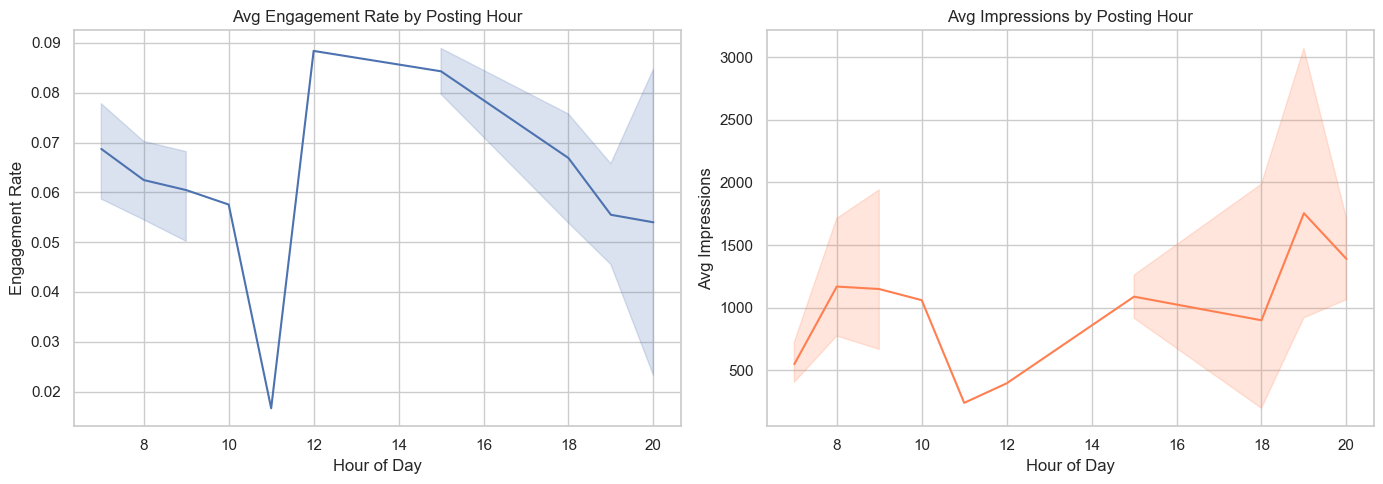

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=df, x="hour", y="engagement_rate", estimator="mean", ax=axes[0])
axes[0].set_title("Avg Engagement Rate by Posting Hour")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Engagement Rate")

sns.lineplot(data=df, x="hour", y="impressions", estimator="mean", ax=axes[1], color="coral")
axes[1].set_title("Avg Impressions by Posting Hour")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Avg Impressions")

plt.tight_layout()
plt.show()

**Interpretation:** Posts published between **7–8 AM** and around **12–15** tend to show higher
engagement rates, while evening posts (19–20) attract more raw impressions but lower audience
engagement. Several time slots have fewer than 5 posts, so patterns should not be over-generalised.

### 8.2 Day of Week

Beyond the hour of posting, we examine whether the **day of the week** is associated with
differences in engagement and reach.

In [22]:
WEEKDAY_ORDER = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]

weekday_perf = (
    df.groupby("weekday")[["engagement_rate", "interactions", "impressions"]]
    .mean()
    .reindex(WEEKDAY_ORDER)
    .dropna(how="all")
)

posts_per_weekday = df["weekday"].value_counts().reindex(WEEKDAY_ORDER).dropna()

print("Average performance by day of week:")
print(weekday_perf.round(4))
print("\nNumber of posts per day:")
print(posts_per_weekday)

Average performance by day of week:
           engagement_rate  interactions  impressions
weekday                                              
Sunday              0.0576       60.7000    1553.7000
Monday              0.0550       45.1429    1141.8571
Tuesday             0.0591       65.1053    1443.4737
Wednesday           0.0671       48.7500     785.6667
Thursday            0.0711       52.8182     774.0000
Friday              0.0691       50.2000     637.6000
Saturday            0.0233       40.0000    1716.0000

Number of posts per day:
weekday
Sunday       23
Monday       11
Tuesday      26
Wednesday    21
Thursday     14
Friday       10
Saturday      6
Name: count, dtype: int64


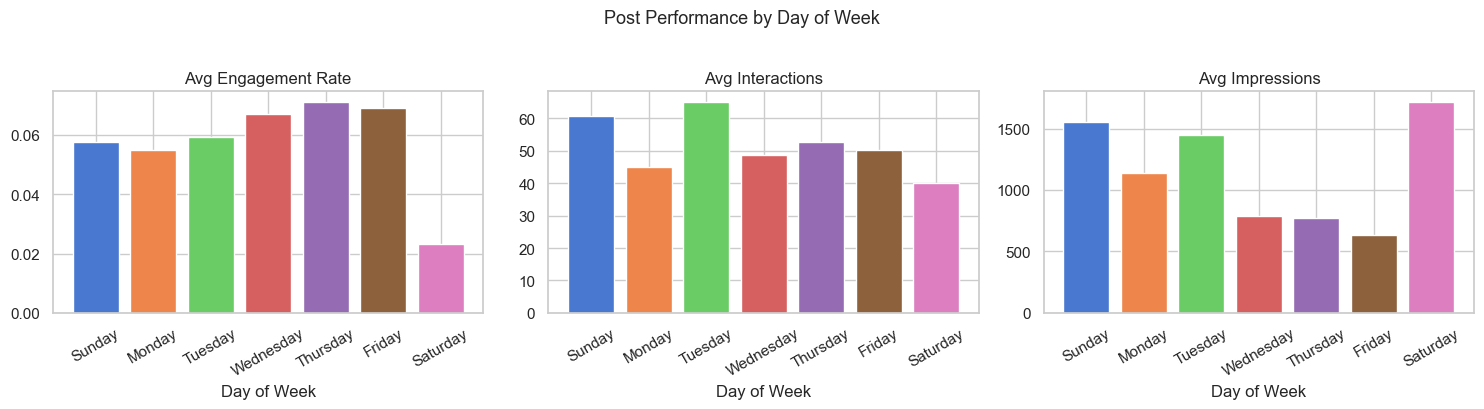

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metrics = [
    ("engagement_rate", "Avg Engagement Rate"),
    ("interactions",    "Avg Interactions"),
    ("impressions",     "Avg Impressions"),
]

for ax, (col, label) in zip(axes, metrics):
    ax.bar(
        weekday_perf.index,
        weekday_perf[col],
        color=sns.color_palette("muted", len(weekday_perf)),
    )
    ax.set_title(label)
    ax.set_xlabel("Day of Week")
    ax.tick_params(axis="x", rotation=30)

plt.suptitle("Post Performance by Day of Week", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 9. Key Findings Summary

| Theme | Finding |
|---|---|
| **Post types** | Photos dominate the dataset (86/111 posts). Content posts (text-only) achieve higher audience engagement despite lower algorithmic reach. Reels are few but tend to land in the "Audience Favorite" quadrant. |
| **Engagement rate** | Mean ≈ 6.2 %, mildly negatively skewed — most posts cluster near the mean, with a handful of outliers on the high end. |
| **Impressions** | Highly right-skewed (a few posts get very high reach). Correlation with interactions is moderate (~0.59), meaning high reach does not always translate to high engagement. |
| **Post categories** | ~46 % of posts are "Low Performance"; ~19 % reach "Viral" status; "Audience Favorites" and "Algorithm Pushed" are roughly equal at ~19 % each. |
| **Posting hour** | Morning slots (7–8 h) and midday (12, 15 h) show higher engagement rates; evening slots (19–20 h) attract more impressions. |
| **Day of week** | Patterns vary — inspect the bar charts above for the specific page's best days (limited sample sizes apply). |